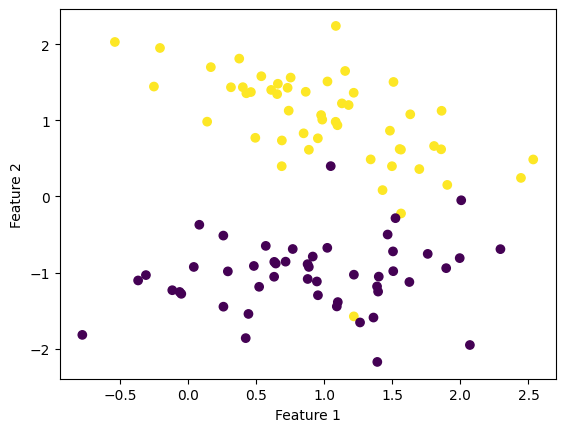

In [6]:
from matplotlib import pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(
    n_features = 2,
    n_redundant = 0,
    n_informative = 2,
    n_clusters_per_class = 1,
    n_classes = 2,
    random_state = 35
)
plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate_line(slope, offset, X, y):
  line=slope*X[:,0]+offset
  labels_v1 = (X[:, 1] > line).astype(int)
  labels_v2 = (X[:, 1] < line).astype(int)
  metrics = {
        "accuracy": max(accuracy_score(y, labels_v1), accuracy_score(y, labels_v2)),
        "precision": max(precision_score(y, labels_v1, zero_division=0),precision_score(y, labels_v2, zero_division=0)),
        "recall": max(recall_score(y, labels_v1, zero_division=0),recall_score(y, labels_v2, zero_division=0)),
        "f1": max(f1_score(y, labels_v1, zero_division=0),f1_score(y, labels_v2, zero_division=0))
  }
  return metrics

In [8]:
import numpy as np
slopes = np.linspace(-5,5,100)
offsets = np.linspace(-5,5,100)
best_score = -1
best_params = (0, 0)
best_metrics = {}
for m in slopes:
    for b in offsets:
        current_metrics = evaluate_line(m, b, X, y)
        score = current_metrics["accuracy"]
        if score > best_score:
            best_score = score
            best_params = (m, b)
            best_metrics = current_metrics

print(f"Best Slope: {best_params[0]:.2f}")
print(f"Best Offset: {best_params[1]:.2f}")
print("Best Metrics:", best_metrics)

Best Slope: -0.45
Best Offset: 0.45
Best Metrics: {'accuracy': 0.97, 'precision': 0.9615384615384616, 'recall': 0.9803921568627451, 'f1': 0.970873786407767}


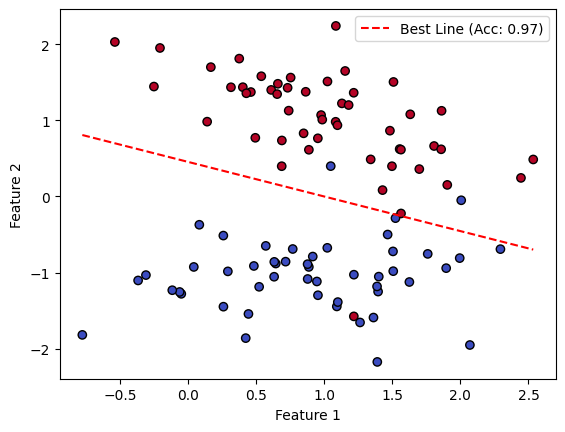

In [9]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k')

x_vals = np.array([X[:,0].min(), X[:,0].max()])
y_vals = best_params[0] * x_vals + best_params[1]

plt.plot(x_vals, y_vals, '--r', label=f'Best Line (Acc: {best_score:.2f})')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [18]:
def evaluate_circle(x_c,y_c,r,X,y):
  distance_sq=(X[:,0]-x_c)**2 +(X[:,1]-y_c)**2
  labels = (distance_sq <= r**2).astype(int)
  metrics = {
        "accuracy": accuracy_score(y, labels),
        "precision": precision_score(y, labels, zero_division=0),
        "recall": recall_score(y, labels, zero_division=0),
        "f1": f1_score(y, labels, zero_division=0)
  }
  return metrics
xcs = np.linspace(-2, 2, 40)
ycs = np.linspace(-2, 2, 40)
rs = np.linspace(0.1, 3, 40)
best_score = -1
best_params = (0, 0, 0)
for xc in xcs:
    for yc in ycs:
        for r in rs:
            res = evaluate_circle(xc, yc, r, X, y)
            score = res["f1"]

            if score > best_score:
                best_score = score
                best_params = (xc, yc, r)
print(f"Best Circle: Center=({best_params[0]:.2f}, {best_params[1]:.2f}), Radius={best_params[2]:.2f}")

Best Circle: Center=(0.97, 2.00), Radius=2.33


In [24]:
final_res = evaluate_circle(0.97, 2.00, 2.33, X, y)
print(final_res)

{'accuracy': 0.97, 'precision': 0.9615384615384616, 'recall': 0.9803921568627451, 'f1': 0.970873786407767}


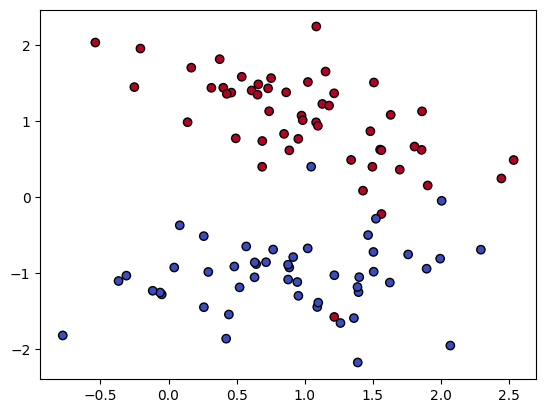

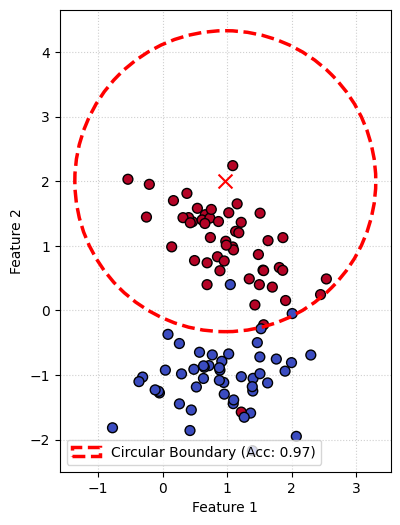

In [25]:
import matplotlib.patches as patches
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k')
best_xc, best_yc, best_r = 0.97, 2.00, 2.33
best_acc = 0.97
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=50, zorder=2)
circle = patches.Circle(
    (best_xc, best_yc),
    radius=best_r,
    edgecolor='red',
    facecolor='none',
    linestyle='--',
    linewidth=2.5,
    label=f'Circular Boundary (Acc: {best_acc:.2f})',
    zorder=3
)
ax.add_patch(circle)
ax.scatter(best_xc, best_yc, color='red', marker='x', s=100, zorder=4)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_aspect('equal', adjustable='box')
plt.show()